## Fase 3: Preprocesamiento y Reducción de Dimensionalidad

El **preprocesamiento** convierte los datos "en bruto" a un formato que los algoritmos de Machine Learning puedan procesar correctamente. La mayoría de modelos solo trabajan con números, y muchos requieren que los números estén en escalas similares.

### 3.1 Limpieza: Eliminación de Columnas Irrelevantes

In [ ]:
# Columnas a eliminar y justificación
cols_eliminar = {
    'EmployeeCount': 'Constante (siempre = 1). No aporta información.',
    'EmployeeNumber': 'Identificador único. No tiene valor predictivo.',
    'Over18': 'Constante (siempre = Y). Sin variabilidad.',
    'StandardHours': 'Constante (siempre = 80). Sin variabilidad.'
}

print("Columnas eliminadas:")
for col, razon in cols_eliminar.items():
    print(f"  ✗ {col}: {razon}")

df_clean = df.drop(columns=list(cols_eliminar.keys()))
df_clean = df_clean.drop(columns=['Attrition_bin'], errors='ignore')  # Columna auxiliar del EDA
print(f"\nDimensiones tras limpieza: {df_clean.shape}")
print(f"  → De 35 columnas quedamos con {df_clean.shape[1]} variables útiles.")

Columnas eliminadas:
  ✗ EmployeeCount: Constante (siempre = 1). No aporta información.
  ✗ EmployeeNumber: Identificador único. No tiene valor predictivo.
  ✗ Over18: Constante (siempre = Y). Sin variabilidad.
  ✗ StandardHours: Constante (siempre = 80). Sin variabilidad.

Dimensiones tras limpieza: (1470, 31)
  → De 35 columnas quedamos con 31 variables útiles.


### 3.2 Codificación de Variables Categóricas

Los algoritmos necesitan números. Las variables de texto deben convertirse.

**Estrategia correcta por tipo de variable:**
- **Binarias** (Sí/No, Hombre/Mujer): **Label Encoding** (0 y 1). No introduce distancias artificiales.
- **Nominales sin orden** (Departamento, Rol, etc.): **One-Hot Encoding**. Crea una columna por categoría (0 o 1). Si usáramos Label Encoding aquí, el algoritmo pensaría que "Sales" (2) > "HR" (1) > "R&D" (0), lo cual sería incorrecto.
- **La variable objetivo `Attrition`**: Label Encoding simple (Yes=1, No=0).

In [7]:
from sklearn.preprocessing import LabelEncoder
df_proc = df_clean.copy()

# 1. Codificar la variable objetivo
df_proc['Attrition'] = (df_proc['Attrition'] == 'Yes').astype(int)
print(f"Attrition codificada: Yes → 1, No → 0")
print(f"  Distribución: {df_proc['Attrition'].value_counts().to_dict()}")

# 2. Variables binarias → Label Encoding (0/1)
binary_cols = ['Gender', 'OverTime']
le = LabelEncoder()
for col in binary_cols:
    df_proc[col] = le.fit_transform(df_proc[col])
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# 3. Variables nominales de más de 2 categorías → One-Hot Encoding
nominal_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']

print(f"\nAplicando One-Hot Encoding a: {nominal_cols}")
df_proc = pd.get_dummies(df_proc, columns=nominal_cols, drop_first=False, dtype=int)

print(f"\nDimensiones tras codificación: {df_proc.shape}")
print(f"  → {df_proc.shape[1]} columnas (nuevas columnas por One-Hot Encoding)")
print("\nPrimeras 5 columnas del dataset procesado:")
print(df_proc.columns[:8].tolist())

Attrition codificada: Yes → 1, No → 0
  Distribución: {0: 1233, 1: 237}
  Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
  OverTime: {'No': np.int64(0), 'Yes': np.int64(1)}

Aplicando One-Hot Encoding a: ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']

Dimensiones tras codificación: (1470, 50)
  → 50 columnas (nuevas columnas por One-Hot Encoding)

Primeras 5 columnas del dataset procesado:
['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate']


### 3.3 Escalado de Variables Numéricas

El **escalado** (o normalización) pone todas las variables en la misma escala. Sin esto, una variable como `MonthlyIncome` (rango: 1,000–20,000) dominaría sobre `Age` (rango: 18–60) en algoritmos basados en distancias (como KNN o SVM) o en gradiente.

**StandardScaler** transforma cada variable para que tenga media 0 y desviación estándar 1. Formula: `z = (x - media) / std`.

In [ ]:
from sklearn.preprocessing import StandardScaler
# Separar features y target antes de escalar
y = df_proc['Attrition'].copy()
X = df_proc.drop(columns=['Attrition'])

# Escalar todas las features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Verificar el resultado
print("Verificación del escalado (deben estar cerca de media≈0, std≈1):")
check = pd.DataFrame({
    'Media post-escalado': X_scaled_df[['Age', 'MonthlyIncome', 'YearsAtCompany']].mean().round(4),
    'Std post-escalado':   X_scaled_df[['Age', 'MonthlyIncome', 'YearsAtCompany']].std().round(4)
})
print(check)

print(f"\nShape final de X: {X_scaled.shape}")
print(f"Shape de y: {y.shape}")
print("\n✓ Dataset listo para modelado.")

Verificación del escalado (deben estar cerca de media≈0, std≈1):
                Media post-escalado  Std post-escalado
Age                            -0.0             1.0003
MonthlyIncome                  -0.0             1.0003
YearsAtCompany                 -0.0             1.0003

Shape final de X: (1470, 49)
Shape de y: (1470,)

✓ Dataset listo para modelado.


### 3.4 Reducción de Dimensionalidad — PCA

El **Análisis de Componentes Principales (PCA)** reduce la cantidad de variables creando nuevas variables (componentes) que son combinaciones lineales de las originales. Cada componente captura la mayor varianza posible.

**¿Por qué usarlo?** Con muchas variables correlacionadas, PCA elimina la redundancia y permite visualizar datos de alta dimensión en 2D o 3D.

  Componentes para 80% varianza: 25
  Componentes para 90% varianza: 30
  Componentes para 95% varianza: 34


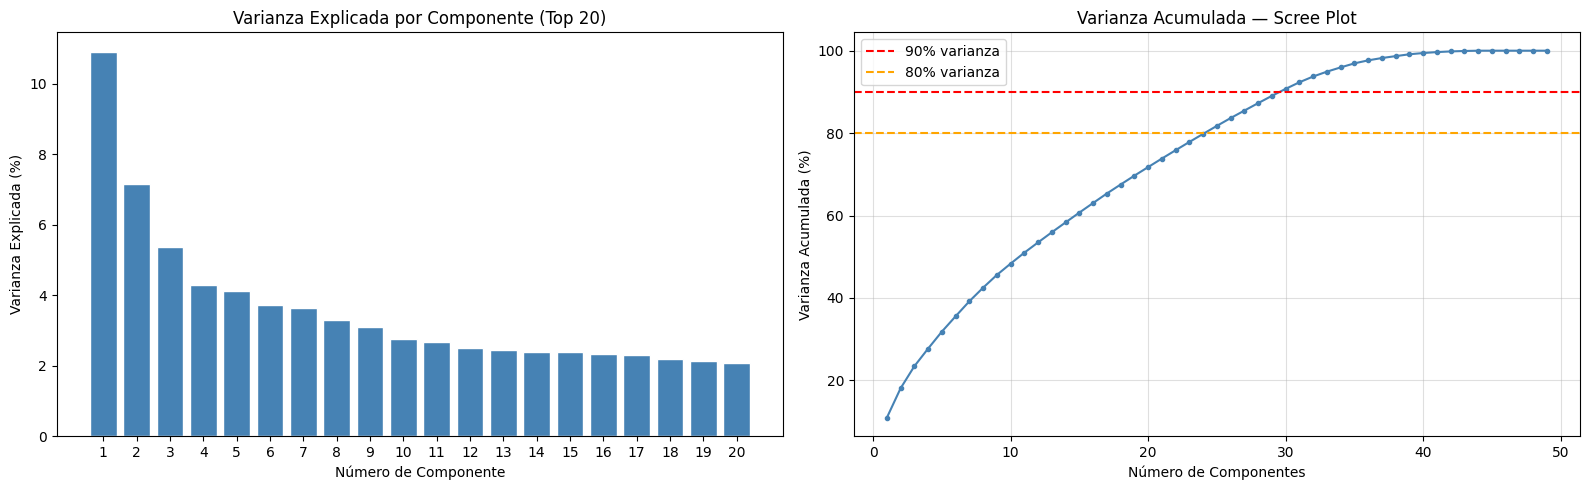

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# --- Scree Plot: determinar número óptimo de componentes ---
pca_full = PCA().fit(X_scaled)
varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

# Encontrar el número de componentes para 80%, 90% y 95% de varianza
for umbral in [0.80, 0.90, 0.95]:
    n_comp = np.argmax(varianza_acumulada >= umbral) + 1
    print(f"  Componentes para {umbral*100:.0f}% varianza: {n_comp}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Varianza por componente
axes[0].bar(range(1, 21), pca_full.explained_variance_ratio_[:20] * 100, 
            color='steelblue', edgecolor='white')
axes[0].set_xlabel('Número de Componente')
axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].set_title('Varianza Explicada por Componente (Top 20)')
axes[0].set_xticks(range(1, 21))

# Varianza acumulada
axes[1].plot(range(1, len(varianza_acumulada)+1), varianza_acumulada * 100, 
             marker='o', markersize=3, color='steelblue', linewidth=1.5)
axes[1].axhline(y=90, color='red',    linestyle='--', label='90% varianza')
axes[1].axhline(y=80, color='orange', linestyle='--', label='80% varianza')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Acumulada (%)')
axes[1].set_title('Varianza Acumulada — Scree Plot')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

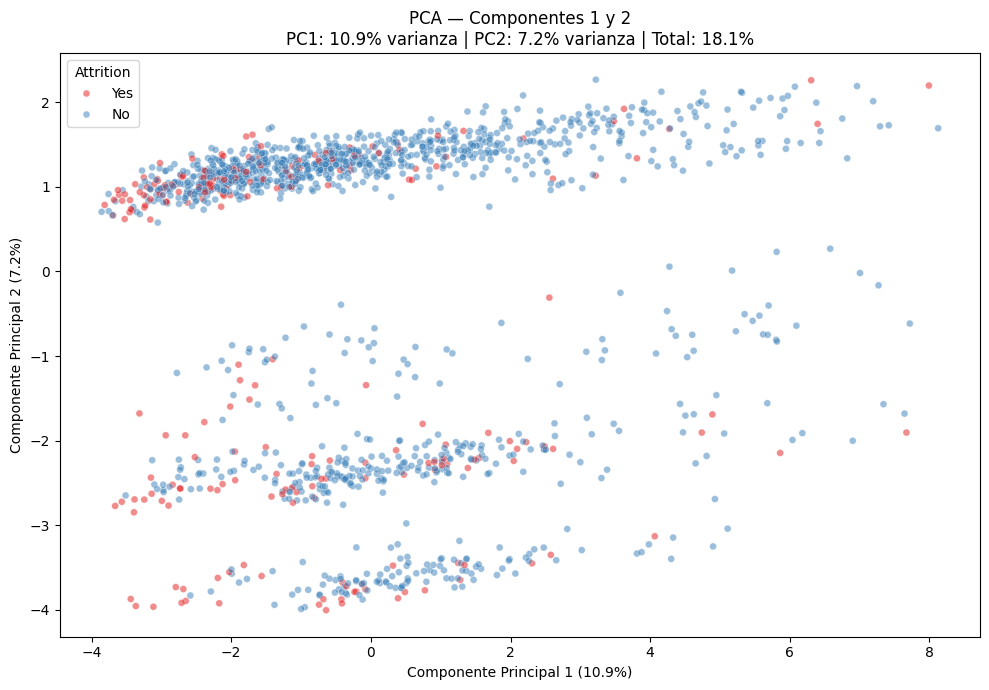


Interpretación del scatter PCA:
  • Existe considerable solapamiento entre Attrition=Yes y No en el espacio PCA 2D.
  • Esto indica que los 2 primeros componentes no son suficientes para separar
    linealmente las clases. Se necesitarían más componentes o modelos no lineales.
  • Los puntos rojos (desertores) tienden a concentrarse ligeramente en
    valores más negativos de PC1, consistente con los hallazgos del EDA
    (menores ingresos, menos experiencia).



In [15]:
import seaborn as sns
# --- Visualización 2D: primeros 2 componentes ---
pca_2 = PCA(n_components=2)
pca_results = pca_2.fit_transform(X_scaled)

pca_df = pd.DataFrame(pca_results, columns=['PC1', 'PC2'])
pca_df['Attrition'] = y.values
pca_df['Attrition_label'] = pca_df['Attrition'].map({1: 'Yes', 0: 'No'})

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df, x='PC1', y='PC2', 
    hue='Attrition_label',
    palette={'Yes': '#e41a1c', 'No': '#377eb8'},
    alpha=0.5, s=25
)
plt.title(
    f'PCA — Componentes 1 y 2\n'
    f'PC1: {pca_2.explained_variance_ratio_[0]*100:.1f}% varianza | '
    f'PC2: {pca_2.explained_variance_ratio_[1]*100:.1f}% varianza | '
    f'Total: {sum(pca_2.explained_variance_ratio_)*100:.1f}%'
)
plt.xlabel(f'Componente Principal 1 ({pca_2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Componente Principal 2 ({pca_2.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(title='Attrition')
plt.tight_layout()
plt.show()

print("""
Interpretación del scatter PCA:
  • Existe considerable solapamiento entre Attrition=Yes y No en el espacio PCA 2D.
  • Esto indica que los 2 primeros componentes no son suficientes para separar
    linealmente las clases. Se necesitarían más componentes o modelos no lineales.
  • Los puntos rojos (desertores) tienden a concentrarse ligeramente en
    valores más negativos de PC1, consistente con los hallazgos del EDA
    (menores ingresos, menos experiencia).
""")

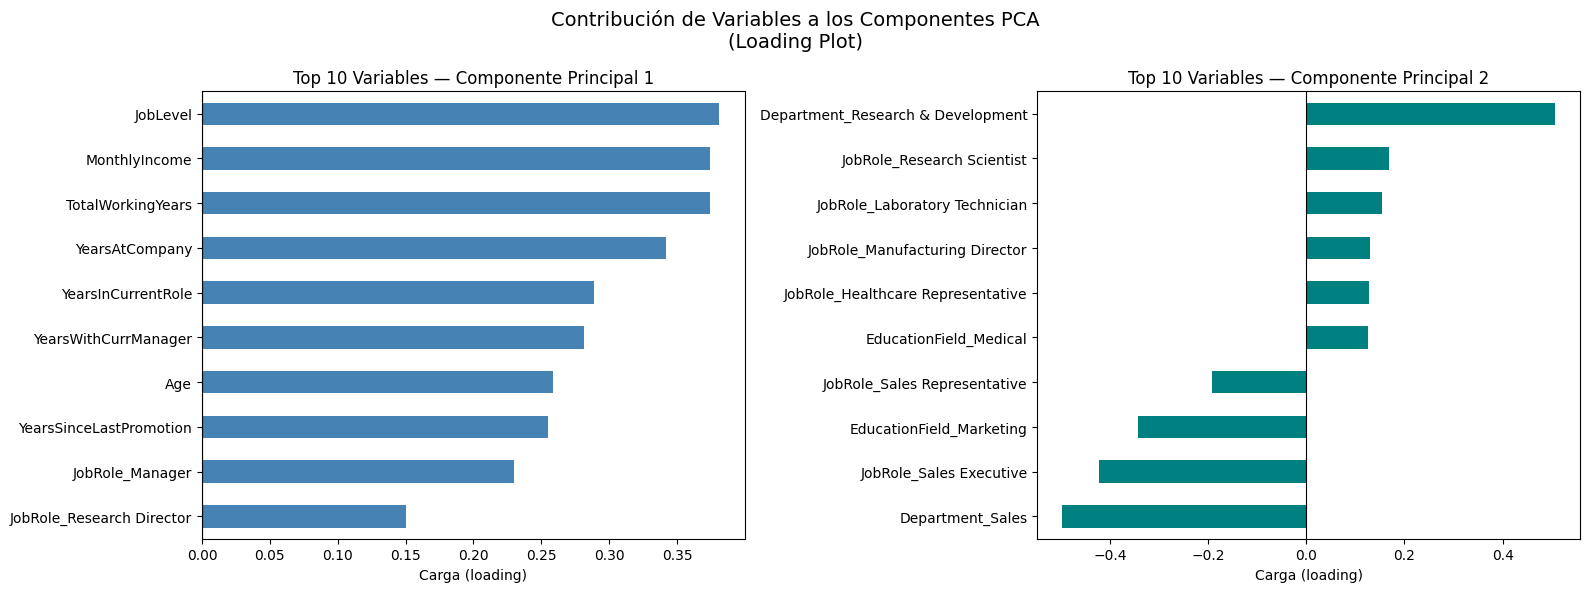


Interpretación del Loading Plot:
  • PC1 está dominado por variables de EXPERIENCIA y CARGO:
    JobLevel, TotalWorkingYears, MonthlyIncome, YearsAtCompany.
    Es una dimensión que representa la 'seniority' del empleado.

  • PC2 captura otras dimensiones como satisfacción o características
    personales no cubiertas por PC1.

  • Un loading positivo alto significa que valores altos de esa variable
    empujan al empleado hacia la derecha en el gráfico PCA.
    Un loading negativo los empuja hacia la izquierda.



In [16]:
# --- Biplot: qué variables contribuyen más a cada componente ---
# Esto muestra la 'carga' (loading) de cada variable original en PC1 y PC2

loadings = pd.DataFrame(
    pca_2.components_.T,
    index=X.columns,
    columns=['PC1', 'PC2']
)

# Top 10 variables que más contribuyen a PC1 y PC2
top_pc1 = loadings['PC1'].abs().nlargest(10)
top_pc2 = loadings['PC2'].abs().nlargest(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

loadings.loc[top_pc1.index, 'PC1'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Variables — Componente Principal 1')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Carga (loading)')

loadings.loc[top_pc2.index, 'PC2'].sort_values().plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Top 10 Variables — Componente Principal 2')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Carga (loading)')

plt.suptitle('Contribución de Variables a los Componentes PCA\n(Loading Plot)', fontsize=14)
plt.tight_layout()
plt.show()

print("""
Interpretación del Loading Plot:
  • PC1 está dominado por variables de EXPERIENCIA y CARGO:
    JobLevel, TotalWorkingYears, MonthlyIncome, YearsAtCompany.
    Es una dimensión que representa la 'seniority' del empleado.

  • PC2 captura otras dimensiones como satisfacción o características
    personales no cubiertas por PC1.

  • Un loading positivo alto significa que valores altos de esa variable
    empujan al empleado hacia la derecha en el gráfico PCA.
    Un loading negativo los empuja hacia la izquierda.
""")

### 3.5 Dataset Final Procesado

In [17]:
# Guardar el dataset preprocesado para uso en modelado futuro
df_final = pd.DataFrame(X_scaled, columns=X.columns)
df_final['Attrition'] = y.values

print("=" * 50)
print("  RESUMEN DE PREPROCESAMIENTO")
print("=" * 50)
print(f"  Dataset original:        {df.shape}")
print(f"  Tras limpieza:           {df_clean.shape}")
print(f"  Tras codificación:       {df_proc.shape}")
print(f"  Tras escalado:           {X_scaled.shape} (features)")
print(f"  Variable objetivo (y):   {y.shape} | Deserción: {y.sum()} casos")
print("")
print("  Técnicas aplicadas:")
print("    ✓ Eliminación columnas constantes (4 columnas)")
print("    ✓ Label Encoding para binarias (Gender, OverTime, Attrition)")
print("    ✓ One-Hot Encoding para nominales (5 variables)")
print("    ✓ StandardScaler para todas las features numéricas")
print("    ✓ PCA: análisis de varianza + loading plot")
print("")
print("  Componentes PCA para 90% de varianza explicada:", 
      np.argmax(varianza_acumulada >= 0.90) + 1)
print("=" * 50)
print("\n✓ Dataset listo para modelado predictivo (Fase 4).")

  RESUMEN DE PREPROCESAMIENTO
  Dataset original:        (1470, 35)
  Tras limpieza:           (1470, 31)
  Tras codificación:       (1470, 50)
  Tras escalado:           (1470, 49) (features)
  Variable objetivo (y):   (1470,) | Deserción: 237 casos

  Técnicas aplicadas:
    ✓ Eliminación columnas constantes (4 columnas)
    ✓ Label Encoding para binarias (Gender, OverTime, Attrition)
    ✓ One-Hot Encoding para nominales (5 variables)
    ✓ StandardScaler para todas las features numéricas
    ✓ PCA: análisis de varianza + loading plot

  Componentes PCA para 90% de varianza explicada: 30

✓ Dataset listo para modelado predictivo (Fase 4).


---
## Conclusión General

El análisis exploratorio reveló que la deserción de empleados en IBM es un fenómeno **multifactorial** con patrones claros:

1. **Las horas extra** (`OverTime`) son el factor más discriminante: triplica la tasa de deserción.
2. **El salario y la experiencia** están inversamente relacionados con la deserción; los empleados junior y con bajo salario son el grupo de mayor riesgo.
3. **Los primeros 2 años** en la empresa concentran la mayoría de los casos de deserción.
4. **El rol de Sales Representative** presenta la mayor tasa de rotación relativa.
5. El dataset está **desbalanceado** (16% positivos), lo que requerirá técnicas especiales en la fase de modelado.

El preprocesamiento garantiza que los datos estén limpios, codificados y escalados correctamente. La aplicación de **One-Hot Encoding** (en lugar de Label Encoding para todas las categóricas) es una mejora técnica relevante que evita introducir ordenamientos artificiales en variables nominales.

El PCA muestra que la dimensionalidad se puede reducir significativamente sin perder el 90% de la información, aunque el solapamiento entre clases en 2D indica que se requerirán **modelos no lineales** (Random Forest, Gradient Boosting, SVM con kernel RBF) para una predicción efectiva.